In [1]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 




1.5587668030871735


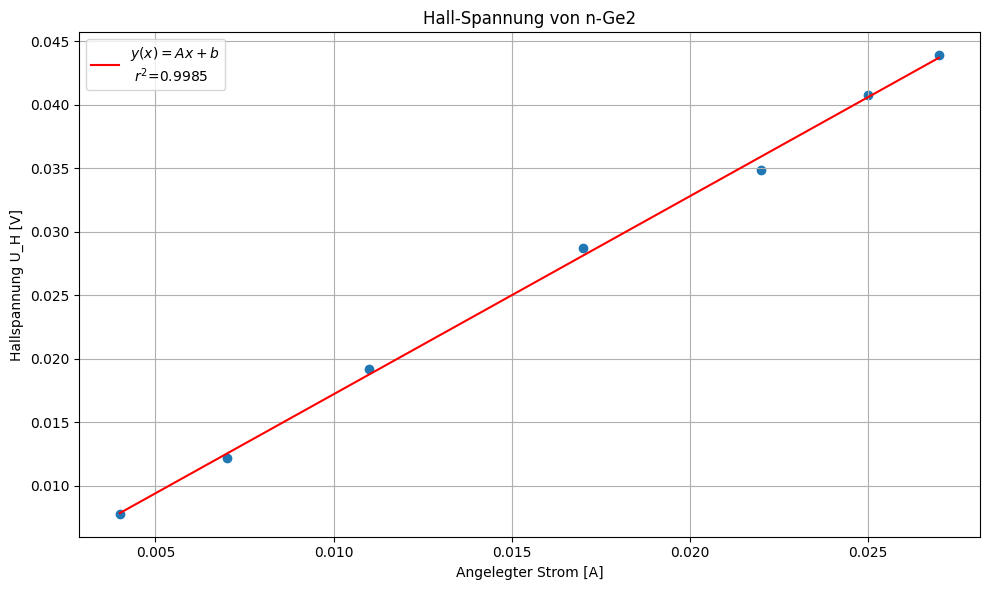

0.2657791508818092


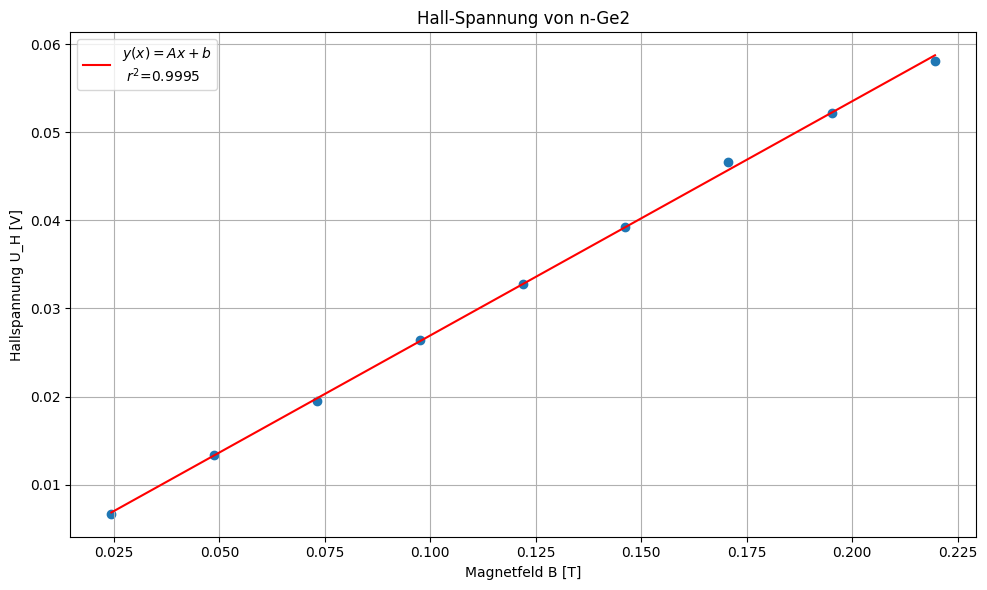

0.27474240183944265


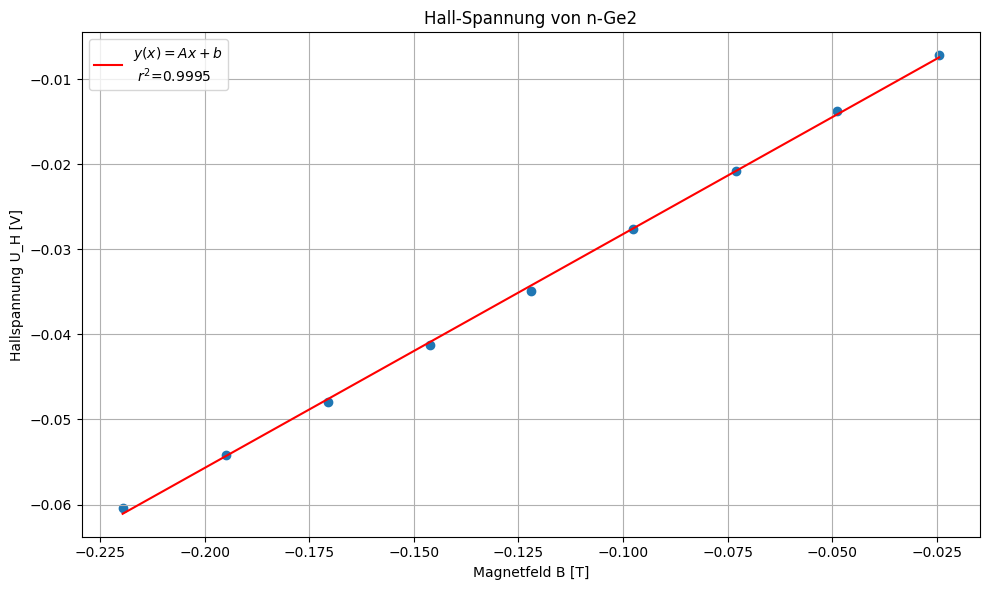

0.2738598048166168


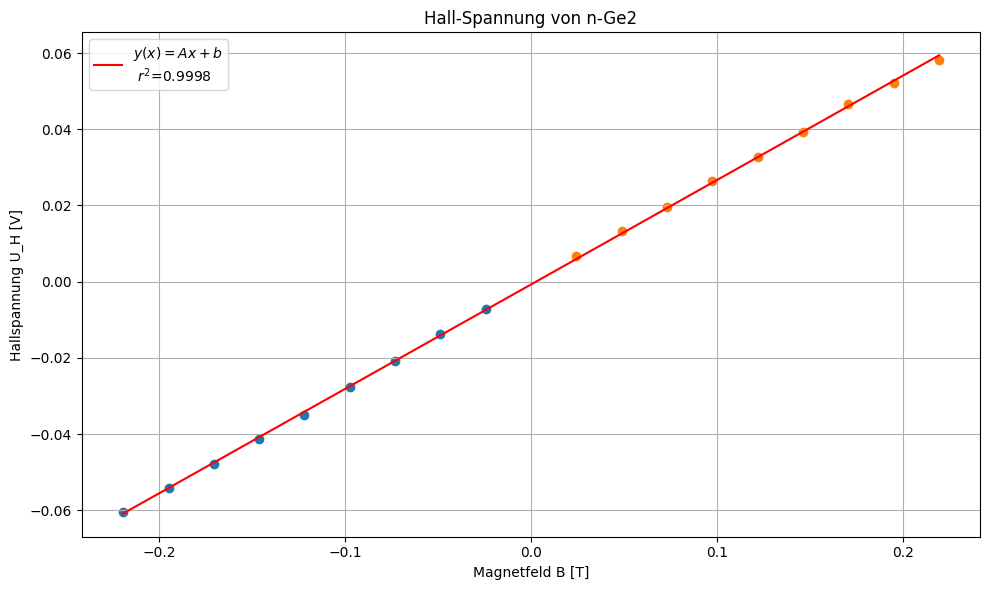

0.24912081717545506


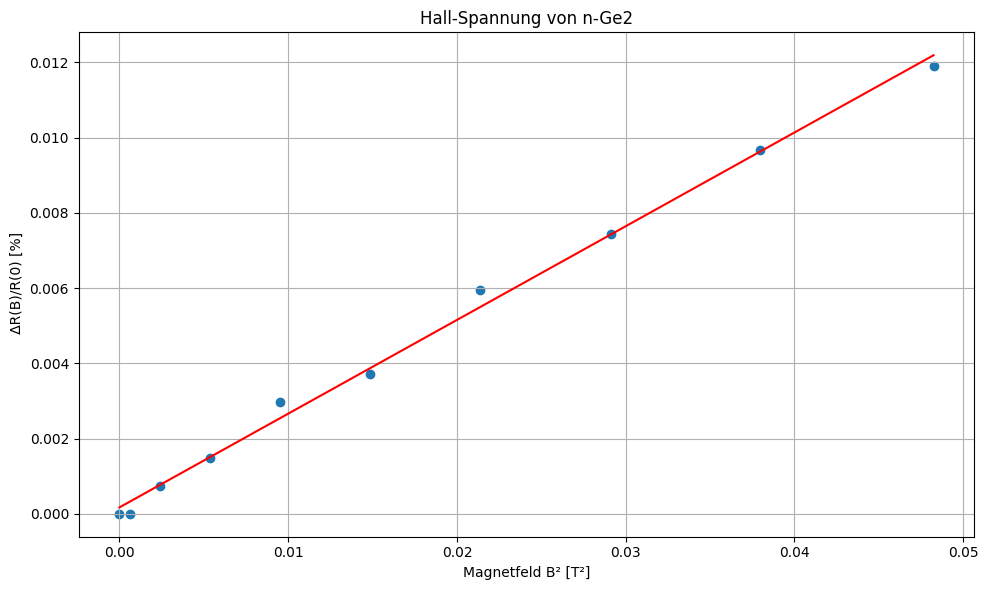

0.214613686972026


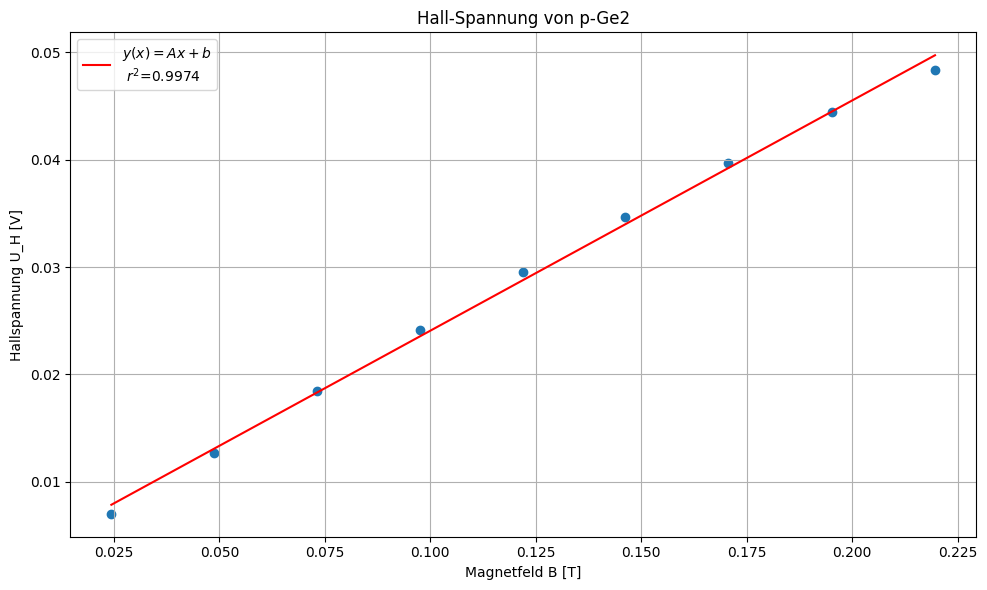

0.21973679850979067


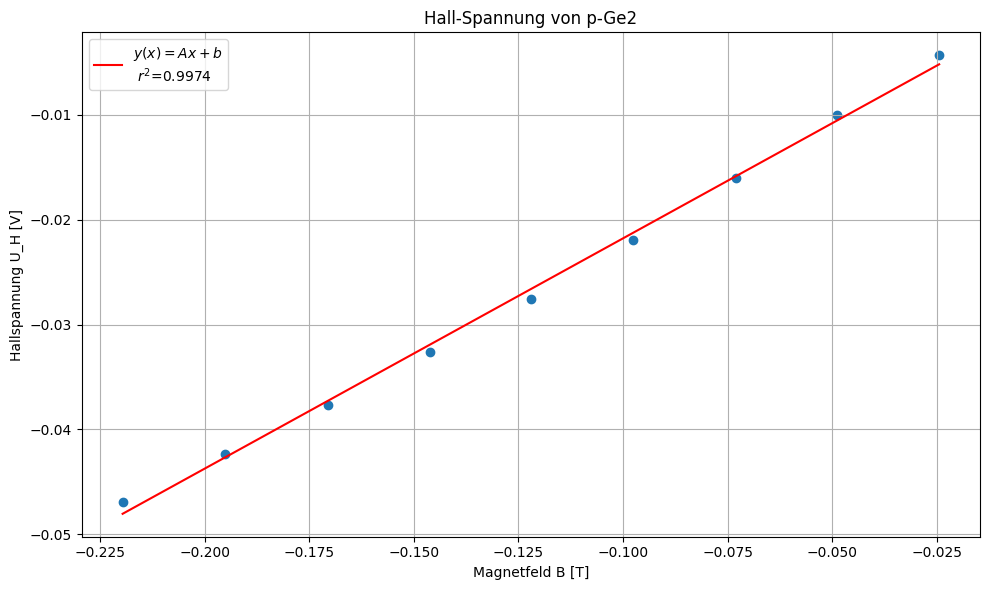

In [ ]:
# Hall-Spannung

# known
l = 20 #mm Länge der Proben
b = 10 #mm Breite der Probe
d = 1 #mm Dicke der Probe
d_p = ufloat(10.0, 0.2) #mm Abstabd der Polschuhe
I_n = 0.025 # A angelegter Strom
def B(I_b, u = False): 
    '''
    Magnetfeld in Abhängigkeit der angelegten Spannung

    Input : I_b [A]

    Outbput : B [mT]
    '''    

    if u:
        B = ufloat(48.70,0.25)*I_b
    else:
        B = 48.70*I_b
    return B


# Versuch 1

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H = np.array([40.8, 7.8, 12.2, 19.2, 28.7, 34.9, 43.9])*10**(-3) # V gemessene Hall-Spannung
I = np.array([0.025, 0.004, 0.007, 0.011, 0.017, 0.022, 0.027]) # A angelegter Strom


# Fit
popt, pcov = curve_fit(Helper.linfit, I, U_H, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(I), max(I), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, I, U_H, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(I, U_H)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Angelegter Strom [A]")
plt.legend()
plt.title("Hall-Spannung von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()




# Versuch 2

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H_2 = np.array([6.7, 13.4, 19.5, 26.4, 32.8, 39.3, 46.6, 52.2, 58.1])*10**(-3) # V gemessene Hall-Spannung
I_b = np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
H_2 = B(I_b)/1000 # B in T

# Fit
popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(H_2), max(H_2), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_2, U_H_2)
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()





# Versuch 3


# Data

U_H_3 = -np.array([7.2, 13.8, 20.8, 27.6, 34.9, 41.3, 47.9, 54.2, 60.4])*10**(-3) # V gemessene Hall-Spannung
I_b_3 = -np.array([0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
H_3 = B(I_b_3)/1000 # B in T

# Fit
popt, pcov = curve_fit(Helper.linfit, H_3, U_H_3, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(H_3), max(H_3), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, H_3, U_H_3, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_3, U_H_3)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()

# Aufgabe 4
H_comb = np.concatenate([H_3, H_2])
U_comb = np.concatenate([U_H_3, U_H_2])

# Fit
popt, pcov = curve_fit(Helper.linfit, H_comb, U_comb, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(H_comb), max(H_comb), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, H_comb, U_comb, Helper.linfit)






# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_3, U_H_3)
plt.scatter(H_2, U_H_2)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung von n-Ge2")
plt.tight_layout()
plt.grid()
plt.show()


# Aufgabe 5



# Data

U_R = np.array([1.344, 1.344, 1.345, 1.346, 1.348, 1.349, 1.352, 1.354, 1.357, 1.360]) # V gemessene Hall-Spannung
I_b_3 = np.array([0, 0.501, 1.002, 1.500, 2.002, 2.504, 3.003, 3.503, 4.000, 4.510]) # A angelegter Strom am Magneten
H_4 = (B(I_b_3)/1000)**2 # B in T
U_del = U_R-1.344

Pro = U_del/1.344

# Fit
popt, pcov = curve_fit(Helper.linfit, H_4, Pro, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(H_4), max(H_4), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, H_4, Pro, Helper.linfit)

# def inverse(x):
#     return x**(1/2)


# def forward(x):
#     return x**2

# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_4, Pro)
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
# plt.xscale('function', functions=(forward, inverse))
plt.ylabel(r" ∆R(B)/R(0) [%]")
plt.xlabel(r"Magnetfeld B² [T²]")
# plt.legend()
plt.title("Magnetowiederstand")
plt.tight_layout()
plt.grid()
plt.show()








# Versuch 6

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H_2 = np.array([7, 12.7, 18.4, 24.1, 29.5, 34.7, 39.7, 44.5, 48.4])*10**(-3) # V gemessene Hall-Spannung
I_b = np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
H_2 = B(I_b)/1000 # B in T

# Fit
popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(H_2), max(H_2), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_2, U_H_2)
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung von p-Ge2")
plt.tight_layout()
plt.grid()
plt.show()


# Versuch 6.2

# gemessen
I_m = ufloat(3.130,0.030) # A
H = B(I_m, True)


# Data

U_H_2 = -np.array([4.3, 10, 16, 21.9, 27.6, 32.6, 37.7, 42.4, 46.9])*10**(-3) # V gemessene Hall-Spannung
I_b = -np.array([0.501, 1.002, 1.500, 2.005, 2.504, 3.003, 3.503, 4.009, 4.510]) # A angelegter Strom am Magneten
U_hs = np.array([1.284, 1.285, 1.287, 1.29, 1.293, 1.298, 1.302, 1.307, 1.311]) # kp warum V ergibt keinen Sinn
H_2 = B(I_b)/1000 # B in T

# Fit
popt_1, pcov_1 = curve_fit(Helper.linfit, H_2, U_H_2, p0=[1, 1])

a_opt, b_opt = popt_1
x_model_1 = np.linspace(min(H_2), max(H_2), 100)
y_model_1 = Helper.linfit(x_model_1, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt_1, H_2, U_H_2, Helper.linfit)


# plot
plt.figure(figsize=(10, 6))
plt.scatter(H_2, U_H_2)
plt.plot(x_model_1, y_model_1, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(V, p, "o")
plt.ylabel(r"Hallspannung U_H [V]")
plt.xlabel(r"Magnetfeld B [T]")
plt.legend()
plt.title("Hall-Spannung von p-Ge2")
plt.tight_layout()
plt.grid()
plt.show()

somethin


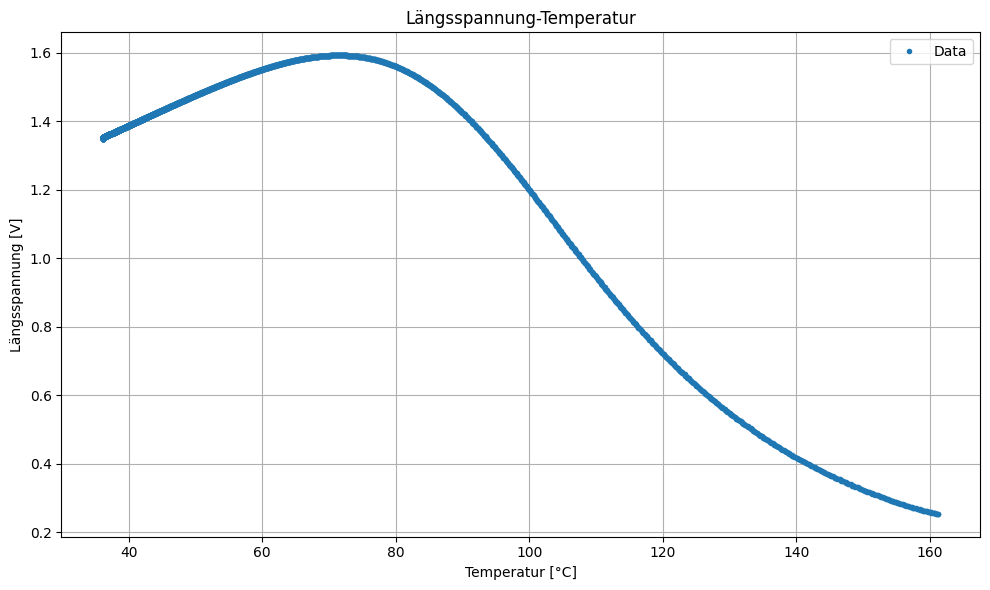

In [2]:
# csv-plots

Data = pd.read_csv("test.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["T"].to_numpy()    # Temperatur Data

U = Data["U"].to_numpy()    # Spannung Data


plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
# plt.fill(T, U, color="C0", alpha=0.25, label="eingeschlossene Fläche")
plt.plot(T, U, '.', linewidth=1, label="Data")
plt.xlabel("Temperatur [°C]")
plt.ylabel("Längsspannung [V]")
plt.title("Längsspannung-Temperatur")
plt.legend()
plt.grid()
plt.tight_layout()